# 1. Import

In [1]:
import importlib
import subprocess
import sys
import time
print(time.ctime() + '\n')

print(sys.version + '\n')

modules = ['numpy', 'scipy', 'matplotlib', 'astropy', 'eazy']
for module in modules:
    try:
        mod = importlib.import_module(module)
        print(f"{module:>20} : {mod.__version__}")
    except ImportError:
        print(f"{module:>20} : NOT installed. Installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", module])
        mod = importlib.import_module(module)
        print(f"{module:>20} : {mod.__version__} (installed now)")

import glob, os
import numpy as np
from astropy.io import fits
import pickle
import tqdm
import warnings
warnings.filterwarnings("ignore")

Sun Nov 30 20:41:23 2025

3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:09:02) [GCC 11.2.0]

               numpy : 2.3.5
               scipy : 1.16.3
          matplotlib : 3.10.7
             astropy : 7.2.0
                eazy : 0.8.5


### Matplotlib setting

In [2]:
from matplotlib import pyplot as plt
%matplotlib inline
from matplotlib import rc, rcParams
rc('axes', linewidth=2)
rc('xtick', top=True, bottom=True, direction='in')
rc('ytick', left=True, right=True, direction='in')

### For installing EAZY-py and the necessary (filter and template) files, please refer to the websites below.
* **[https://github.com/gbrammer/eazy-py](https://github.com/gbrammer/eazy-py)**
* **[https://github.com/gbrammer/eazy-photoz/](https://github.com/gbrammer/eazy-photoz/)**

In [3]:
import eazy
from eazy import photoz

current_path = os.path.abspath(".")
your_eazyfile_path = "/home/jhlee/Downloads/eazy-photoz/"  # the path where you will download 'eazy-photoz'
if not os.path.exists(your_eazyfile_path):
    os.chdir(your_eazyfile_path.split("eazy-photoz")[0])  # move to download path
    os.system("git clone https://github.com/gbrammer/eazy-photoz.git")  # download 'eazy-photoz' file from github
    os.chdir(current_path)
os.environ['EAZYCODE'] = your_eazyfile_path

# 2. Read the input flux file

### For the SMACS0723 field, input fluxes were measured in [Lee, J. H., et al. (2024)](https://ui.adsabs.harvard.edu/abs/2024ApJ...966..113L/abstract), using [SExtractor](https://sextractor.readthedocs.io/en/latest/Introduction.html).
### [Noirot et al. (2023)](https://ui.adsabs.harvard.edu/abs/2023MNRAS.525.1867N/abstract) presented spectroscopic redshifts of 185 objects in this field.
* Combining JWST/NIRISS grism spectroscopy with JWST/NIRSpec and VLT/MUSE redshifts.

In [4]:
input_flux_file = "flux_EAZY_run2p.cat"
with open(input_flux_file, 'r') as f:
    ln1 = f.readline()
column_names = ln1.split()[1:]
print(column_names)

['id', 'z_spec', 'ra', 'dec', 'F236', 'E236', 'F239', 'E239', 'F202', 'E202', 'F203', 'E203', 'F204', 'E204', 'F205', 'E205', 'F363', 'E363', 'F365', 'E365', 'F366', 'E366', 'F375', 'E375', 'F376', 'E376', 'F377', 'E377']


In [5]:
input_flux_data = np.genfromtxt(input_flux_file, encoding='ascii', names=column_names)

In [6]:
print(input_flux_data[:5])  # print the first 5 rows of the data

[(3537., 0.7477, 110.83662, -73.47163, 0.2631, 0.02423, 0.5878 , 0.05414 ,   0.5257, 0.04842,   0.5414, 0.04986,   0.4988, 0.04594,   0.5139, 0.04733,  0.6088, 0.05607,  0.646 , 0.0595 ,  0.6388, 0.05884,  0.6726, 0.06195,  0.5491, 0.05057, 0.3719, 0.03425)
 (3691., 0.7953, 110.79554, -73.47007, 0.2161, 0.0199 , 0.316  , 0.0291  ,   0.2571, 0.02368,   0.373 , 0.03436,   0.2817, 0.02595,   0.2272, 0.02092,  0.3118, 0.02872,  0.2848, 0.02624,  0.311 , 0.02864,  0.2959, 0.02725,  0.2408, 0.02218, 0.1674, 0.01542)
 (3808., 1.9697, 110.79647, -73.47057, 0.1321, 0.01216, 0.2687 , 0.02475 ,   0.5746, 0.05292, -99.    , 0.04512,   1.161 , 0.1069 , -99.    , 0.08294,  0.4002, 0.03686,  1.469 , 0.1353 ,  2.724 , 0.2509 ,  3.971 , 0.3658 ,  5.724 , 0.5272 , 7.139 , 0.6575 )
 (3839., 1.3832, 110.82997, -73.46992, 0.1064, 0.0098 , 0.09932, 0.009148,   0.2798, 0.02577,   0.2985, 0.02749,   0.2874, 0.02647,   0.3581, 0.03298,  0.191 , 0.01759,  0.349 , 0.03215,  0.3403, 0.03134,  0.3762, 0.03465,  0.

# 3. Set filters

### For the SMACS0723 cluster, there are HST and JWST multiwavelength photometric data.
* HST: **F606W, F814W** ([ACS](https://hst-docs.stsci.edu/acsihb/chapter-5-imaging/5-1-imaging-overview)), **F105W, F125W, F140W, F160W** ([HST/WFC3-IR](https://hst-docs.stsci.edu/wfc3ihb/chapter-7-ir-imaging-with-wfc3/7-6-ir-optical-performance))
* JWST: **F090W, F150W, F200W** ([NIRCam short wavelength channel](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-instrumentation/nircam-filters)), **F277W, F356W, F444W** ([NIRCam long wavelength channel](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-instrumentation/nircam-filters))

In [7]:
bands_hst  = ['f606w', 'f814w',    # HST/ACS
              'f105w', 'f125w', 'f140w', 'f160w']    # HST/WFC3-IR
bands_jwst = ['f090w', 'f150w', 'f200w',    # JWST/NIRCam short wavelength channel
              'f277w', 'f356w', 'f444w']    # JWST/NIRCAm long wavelength channel
id_flt_hst  = [236, 239,
               202, 203, 204, 205]    # from 'your_eazyfile_path/filters/FILTER.RES.latest.info' file
id_flt_jwst = [363, 365, 366,
               375, 376, 377]    # from 'FILTER.RES.latest.info' file

### Creating ``*.translate`` file
#### ``*.translate`` file is used to interpret the filter information in the input flux catalog.

In [8]:
def create_translate(band_name, band_id, out):
    with open(out, "w") as fw:
        for i in range(len(band_name)):
            fw.write(band_name[i]+f"_tot_1   F{band_id[i]:d}\n")
            fw.write(band_name[i]+f"_etot_1  E{band_id[i]:d}\n")

translate_file = "total.translate"
create_translate(bands_hst+bands_jwst, id_flt_hst+id_flt_jwst, translate_file)

# 4. Set up input parameters for eazy-py

### Defining a function for input parameters

In [9]:
def eazypy_input(catalog, dir_output, output_file,
                 filters="FILTER.RES.latest", temp_file="carnall_sfhz_13.param", #temp_combo="a",
                 wave_file="lambda.def", temperr_file="template_error_cosmos2020.txt",
                 # laf_file=dir_temp+"LAFcoeff.txt", dla_file=dir_temp+"DLAcoeff.txt",
                 apply_prior=False, prior_file="prior_F160W_TAO.dat", prior_filter=205,
                 fix_zspec=False, zmin=0.01, zmax=12.0, zstep=0.01):#, H0=68.4, Omega_M=0.3, Omega_L=0.7):

    params = {}
    params['FILTERS_RES']       = filters
    params['TEMPLATES_FILE']    = temp_file  #'carnall_sfhz_13.param'
    params['WAVELENGTH_FILE ']  = wave_file
    params['TEMP_ERR_FILE']     = temperr_file

    params['TEMP_ERR_A2']       = 1.0
    params['SYS_ERR']           = 0.05

    params['MW_EBV']            = 0.012
    params['CAT_HAS_EXTCORR']   = True

    params['CATALOG_FILE']      = catalog  #"EAZY_INPUT/flux_EAZY_total_run1.cat"

    if not os.path.exists(dir_output):
        os.system("mkdir "+dir_output)
    params['OUTPUT_DIRECTORY']  = dir_output
    params['MAIN_OUTPUT_FILE']  = output_file  #'output.eazypy'

    params['APPLY_PRIOR']       = apply_prior  #True
    params['PRIOR_FILE']        = prior_file  #"prior_F160W_TAO.dat"
    params['PRIOR_FILTER']      = prior_filter  #365
    params['PRIOR_ABZP']        = 23.9
    params['PRIOR_FLOOR']       = 0.01

    params['FIX_ZSPEC']         = fix_zspec
    params['Z_MIN']             = zmin  #0.05
    params['Z_MAX']             = zmax  #12.0
    params['Z_STEP']            = zstep  #0.005
    params['Z_STEP_TYPE']       = 1

    return params

### Copying necessary files

In [10]:
param_file = "zphot.param.default"
os.system("cp -rpv "+os.path.join(os.getenv('EAZYCODE'),
          'filters/FILTER.RES.latest')+" .")
os.system("cp -rpv "+os.path.join(os.getenv('EAZYCODE'),
          'filters/FILTER.RES.latest.info')+" .")
os.system("cp -rpv "+os.path.join(os.getenv('EAZYCODE'),
          'templates/uvista_nmf/lambda.def')+" .")
os.system("cp -rpv "+os.path.join(os.getenv('EAZYCODE'),
          'templates/template_error_cosmos2020.txt')+" .")
os.system("cp -rpv "+os.path.join(os.getenv('EAZYCODE'),
          'templates/prior_F160W_TAO.dat')+" .")
os.system("cp -rpv "+os.path.join(os.getenv('EAZYCODE'),
          'templates/sfhz/carnall_sfhz_13.param')+" .")
os.system("cp -rpv "+os.path.join(os.getenv('EAZYCODE'),
          'templates/sfhz/carnall_sfhz_13.param.fits')+" .")

'/home/jhlee/Downloads/eazy-photoz/filters/FILTER.RES.latest' -> './FILTER.RES.latest'
'/home/jhlee/Downloads/eazy-photoz/filters/FILTER.RES.latest.info' -> './FILTER.RES.latest.info'
'/home/jhlee/Downloads/eazy-photoz/templates/uvista_nmf/lambda.def' -> './lambda.def'
'/home/jhlee/Downloads/eazy-photoz/templates/template_error_cosmos2020.txt' -> './template_error_cosmos2020.txt'
'/home/jhlee/Downloads/eazy-photoz/templates/prior_F160W_TAO.dat' -> './prior_F160W_TAO.dat'
'/home/jhlee/Downloads/eazy-photoz/templates/sfhz/carnall_sfhz_13.param' -> './carnall_sfhz_13.param'
'/home/jhlee/Downloads/eazy-photoz/templates/sfhz/carnall_sfhz_13.param.fits' -> './carnall_sfhz_13.param.fits'


0

### Setting up the input templates for eazy-py fitting
#### Here we will use [*SFHZ* template sets](https://github.com/gbrammer/eazy-photoz/tree/master/templates/sfhz) for photometric redshift estimation.

In [11]:
dir_input, dir_output = "./", "./"  # current path for input & output
temp_def_file = "carnall_sfhz_13.param"  # template definition file
with open(temp_def_file, 'r') as f:
    ll = f.readlines()
ll

['1 templates/sfhz/corr_sfhz_13_bin0_av0.01.fits 1.0\n',
 '2 templates/sfhz/corr_sfhz_13_bin0_av0.25.fits 1.0\n',
 '3 templates/sfhz/corr_sfhz_13_bin0_av0.50.fits 1.0\n',
 '4 templates/sfhz/corr_sfhz_13_bin0_av1.00.fits 1.0\n',
 '5 templates/sfhz/corr_sfhz_13_bin1_av0.01.fits 1.0\n',
 '6 templates/sfhz/corr_sfhz_13_bin1_av0.25.fits 1.0\n',
 '7 templates/sfhz/corr_sfhz_13_bin1_av0.50.fits 1.0\n',
 '8 templates/sfhz/corr_sfhz_13_bin1_av1.00.fits 1.0\n',
 '9 templates/sfhz/corr_sfhz_13_bin2_av0.01.fits 1.0\n',
 '10 templates/sfhz/corr_sfhz_13_bin2_av0.50.fits 1.0\n',
 '11 templates/sfhz/corr_sfhz_13_bin2_av1.00.fits 1.0\n',
 '12 templates/sfhz/corr_sfhz_13_bin3_av0.01.fits 1.0\n',
 '13 templates/sfhz/corr_sfhz_13_bin3_av0.50.fits 1.0\n',
 '14 templates/sfhz/4590.fits 1.0\n']

In [12]:
with open(temp_def_file, 'w') as f:
    for i in range(len(ll)):
        f.write(ll[i].split()[0]+"  ")
        f.write(os.getenv('EAZYCODE')+ll[i].split()[1]+"  ")  # exact path for eazy-photoz added
        f.write(ll[i].split()[2]+"\n")

In [13]:
ezParam = {'filters':"FILTER.RES.latest", 'wave_file':"lambda.def",
           'temperr_file':"template_error_cosmos2020.txt",
           'apply_prior':True, 'prior_file':"prior_F160W_TAO.dat", 'prior_filter':205, 
           'fix_zspec':False, 'zmin':0.05, 'zmax':12.0, 'zstep':0.005}

params = eazypy_input(input_flux_file, dir_output, output_file="output.eazypy",
                      temp_file=temp_def_file, **ezParam)

# 5. Run eazy-py

### Defining a function for running eazy-py

In [14]:
def start_eazypy(param_file, params, NITER=5, translate_file="zphot.translate",
                 output_prefix="output.eazypy", dir_output="EAZY_OUTPUT",
                 zeropoint_file=None):

    pred = eazy.photoz.PhotoZ(param_file=param_file,
                              translate_file=translate_file,
                              zeropoint_file=zeropoint_file, 
                              params=params,
                              load_prior=True, load_products=False)
 
    if (zeropoint_file == None):
        NBIN = np.minimum(pred.NOBJ//100, 180)
        pred.param.params['VERBOSITY'] = 1.
        for i in range(NITER):
            print('Iteration: ', i)
            sn = pred.fnu/pred.efnu
            clip = (sn > 1).sum(axis=1) > 4 # Generally make this higher to ensure reasonable fits
            pred.iterate_zp_templates(idx=pred.idx[clip], update_templates=False, 
                                      update_zeropoints=True, iter=i, n_proc=8, 
                                      save_templates=False, error_residuals=False, 
                                      NBIN=NBIN, get_spatial_offset=False)
    else:
        pass

    # Turn off error corrections derived above
    pred.set_sys_err(positive=True)

    # Full catalog
    sample = np.isfinite(pred.cat['z_spec'])

    # fit_parallel renamed to fit_catalog 14 May 2021
    pred.fit_catalog(pred.idx[sample], n_proc=8)

    # # Show zspec-zphot comparison
    # fig = pred.zphot_zspec()

    # Derived parameters (z params, RF colors, masses, SFR, unobserved magnitude, etc.)
    warnings.simplefilter('ignore', category=RuntimeWarning)
    zout, hdu = pred.standard_output(rf_pad_width=0.5, rf_max_err=2, 
                                     prior=True, beta_prior=True)
    plt.close('all')

    return pred

### Running eazy-py

In [15]:
pred = start_eazypy(param_file, params, NITER=3, translate_file=translate_file,
                    output_prefix="output.eazypy", dir_output=dir_output,
                    zeropoint_file=None)

Read default param file: zphot.param.default
Read CATALOG_FILE: flux_EAZY_run2p.cat
   >>> NOBJ = 185
F236 E236 (236): hst/ACS_update_sep07/wfc_f606w_t81.dat
F239 E239 (239): hst/ACS_update_sep07/wfc_f814w_t81.dat
F202 E202 (202): hst/wfc3/IR/f105w.dat
F203 E203 (203): hst/wfc3/IR/f125w.dat
F204 E204 (204): hst/wfc3/IR/f140w.dat
F205 E205 (205): hst/wfc3/IR/f160w.dat
F363 E363 (363): jwst_nircam_f090w
F365 E365 (365): jwst_nircam_f150w
F366 E366 (366): jwst_nircam_f200w
F375 E375 (375): jwst_nircam_f277w
F376 E376 (376): jwst_nircam_f356w
F377 E377 (377): jwst_nircam_f444w
Set sys_err = 0.05 (positive=True)
Read PRIOR_FILE:  prior_F160W_TAO.dat
Template grid: carnall_sfhz_13.param (this may take some time)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [01:59<00:00,  8.50s/it]


Template   0: corr_sfhz_13_bin0_av0.01.fits (NZ=14).
Template   1: corr_sfhz_13_bin0_av0.25.fits (NZ=14).
Template   2: corr_sfhz_13_bin0_av0.50.fits (NZ=14).
Template   3: corr_sfhz_13_bin0_av1.00.fits (NZ=14).
Template   4: corr_sfhz_13_bin1_av0.01.fits (NZ=14).
Template   5: corr_sfhz_13_bin1_av0.25.fits (NZ=14).
Template   6: corr_sfhz_13_bin1_av0.50.fits (NZ=14).
Template   7: corr_sfhz_13_bin1_av1.00.fits (NZ=14).
Template   8: corr_sfhz_13_bin2_av0.01.fits (NZ=14).
Template   9: corr_sfhz_13_bin2_av0.50.fits (NZ=14).
Template  10: corr_sfhz_13_bin2_av1.00.fits (NZ=14).
Template  11: corr_sfhz_13_bin3_av0.01.fits (NZ=14).
Template  12: corr_sfhz_13_bin3_av0.50.fits (NZ=14).
Template  13: 4590.fits (NZ=1).
Process templates: 119.609 s


504it [00:00, 14081.41it/s]

Iteration:  0


...

Compute best fits
fit_best: 0.0 s (n_proc=1,  NOBJ=185)
Fit 1.4 s (n_proc=8, NOBJ=185)
Get best fit coeffs & best redshifts
fit_best: 0.1 s (n_proc=1,  NOBJ=185)
Get parameters (UBVJ=[153, 154, 155, 161], simple=False)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 185/185 [00:00<00:00, 315.81it/s]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 185/185 [00:01<00:00, 104.04it/s]


Abs Mag filters [271, 272, 274]
Rest-frame filters:
~~~~~~~~~~~~~~~~~~~ 
   0 RestUV/Tophat_1700_200.dat lambda_c= 1.6989e+03 AB-Vega=1.916 w95=190.7
   1 RestUV/Tophat_2200_200.dat lambda_c= 2.1993e+03 AB-Vega=1.691 w95=191.1
   2 RestUV/Tophat_2800_200.dat lambda_c= 2.7996e+03 AB-Vega=1.465 w95=191.2


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 185/185 [00:00<00:00, 335.07it/s]


### Saving the output eazy-py model

In [16]:
with open("output.eazypy.zphot.pickle","wb") as fw:
    pickle.dump(pred, fw)

# 6. Evaluate the eazy-py model

### Reading the output results

In [17]:
dz, hz = fits.getdata(dir_output+"output.eazypy.zout.fits", ext=1, header=True)

### Plot #1. Comparing the photometric redshifts with spectroscopic redshifts

In [18]:
c = 2.99792e+5  # light speed [km/s]

def plot_comp(z_spec, z_phot, out, ids,
              label_x='', label_y='', title='',
              xmin=0.03, xmax=30.0, slope=0.15):
    
    dz = np.abs(z_spec-z_phot)/(1+z_spec)
    bias = np.nanmedian(np.abs(z_spec-z_phot))
    sigma = 1.48*np.nanmedian(np.abs((z_phot-z_spec)-np.nanmedian(z_phot-z_spec))/(1+z_spec))

    outlier = (dz >= slope) | (np.isnan(z_phot)) | (z_phot <= 0.)
    print(f"Total             : {len(ids):d}")
    print(f"Outliers (w/o NaN): {np.sum(dz >= slope):d}, {100.*np.sum(dz >= slope)/len(ids):.1f}%")
    print(f"Outliers (genuine): {np.sum(outlier):d}, {100.*np.sum(outlier)/len(ids):.1f}%")
    print(f"MAD sigma         : {sigma:.3f}")
    print(f"Bias              : {bias:.3f}")
    print("\n")

    fig, ax = plt.subplots(figsize=(5, 5))

    ax.plot(z_spec, z_phot, 'o', ms=3.0, mew=0.5,
            color='tab:blue', alpha=0.6)
    ax.plot([xmin, xmax], [xmin, xmax], '-', lw=1.5, color='gray', alpha=0.75)

    xx = np.logspace(np.log10(xmin), np.log10(xmax), 1000)
    ax.plot(xx, (1.0-slope)*xx-slope, '--', lw=1.5, color='gray', alpha=0.75)
    ax.plot(xx, (1.0+slope)*xx+slope, '--', lw=1.5, color='gray', alpha=0.75)
    ax.set_xlim([xmin, xmax])
    ax.set_ylim([xmin, xmax])
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(label_x, fontsize=12.0, fontweight='bold')
    ax.set_ylabel(label_y, fontsize=12.0, fontweight='bold')
    ax.tick_params(axis='both', labelsize=12.0)
    ax.tick_params(width=2.0, length=9.0)
    ax.tick_params(width=2.0, length=5.0,which='minor')
    ax.text(0.50, 1.03, title,
            fontsize=12.0, fontweight="bold", color="black",
            ha="center", va="bottom", transform=ax.transAxes)
    ax.text(0.06, 0.94, r"$N$"+f" = {len(ids):d} ({np.sum(outlier):d},"+ \
            f" {100.*np.sum(outlier)/len(ids):.1f}%)",
            fontsize=10.0, color="black",
            ha="left", va="top", transform=ax.transAxes)
    ax.text(0.06, 0.89, r"$\sigma_{\rm NMAD}$"+ \
            f" = {sigma:.3f}",
            fontsize=10.0, color="black",
            ha="left", va="top", transform=ax.transAxes)
    ax.text(0.06, 0.84, r"$Bias$"+ \
            f" = {bias:.3f}",
            fontsize=10.0, color="black",
            ha="left", va="top", transform=ax.transAxes)

    plt.tight_layout()
    plt.savefig(out, dpi=300)
    # plt.show(block=False)
    # plt.close()

Total             : 185
Outliers (w/o NaN): 14, 7.6%
Outliers (genuine): 14, 7.6%
MAD sigma         : 0.034
Bias              : 0.043




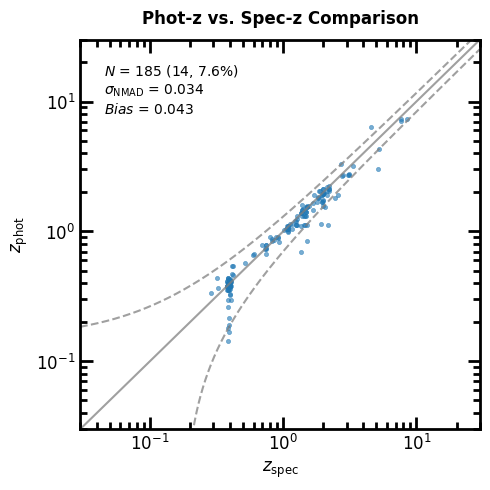

In [19]:
plot_comp(dz['z_spec'], dz['z_phot'], "Fig1-comp_z_eazypy.png", dz['id'],
          label_x=r"$z_{\rm spec}$", label_y=r"$z_{\rm phot}$", title="Phot-z vs. Spec-z Comparison",
          xmin=0.03, xmax=30.0, slope=0.15)

### Plot #2. Spectral energy density (SED) best-fit models

In [20]:
### SED plot
def plot_seds(dir_eazyout, output_fits, output_pickle, objids=None, save_data=False):
    if not (dir_eazyout[-1] == "/"):
        dir_eazyout += "/"
    dir_figs = dir_eazyout+"SED_EAZY/"
    if not os.path.exists(dir_figs):
        os.system("mkdir "+dir_figs)

    dz, hz = fits.getdata(dir_eazyout+output_fits, ext=1, header=True)

    with open(dir_eazyout+output_pickle, "rb") as fr:
        pred = pickle.load(fr)

    if objids is None:
        objids = dz['id']
    n_obj = len(objids)

    for i in tqdm.trange(n_obj):
        objid = objids[i]
        fig, data = pred.show_fit(objid, id_is_idx=False, show_fnu=1,
                                  xlim=[0.3, 9], show_components=True)
        plt.savefig(dir_figs+f"ID-{objid:05d}.png", dpi=300)
        
        if save_data:
            with open(dir_figs+f"ID-{objid:05d}.data", "wb") as fw:
                pickle.dump(data, fw)                    

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.62it/s]


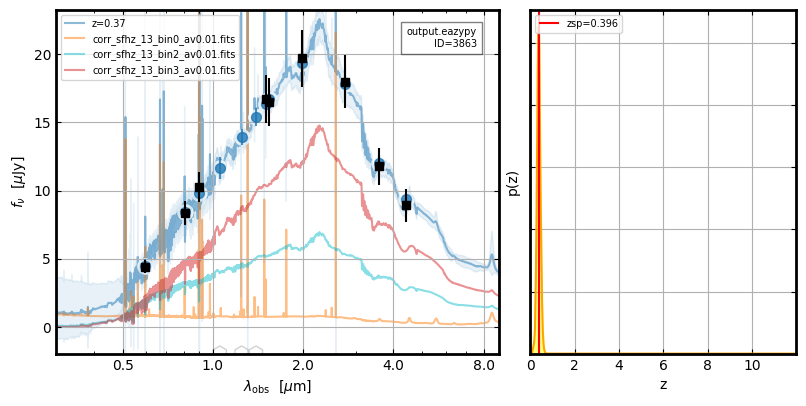

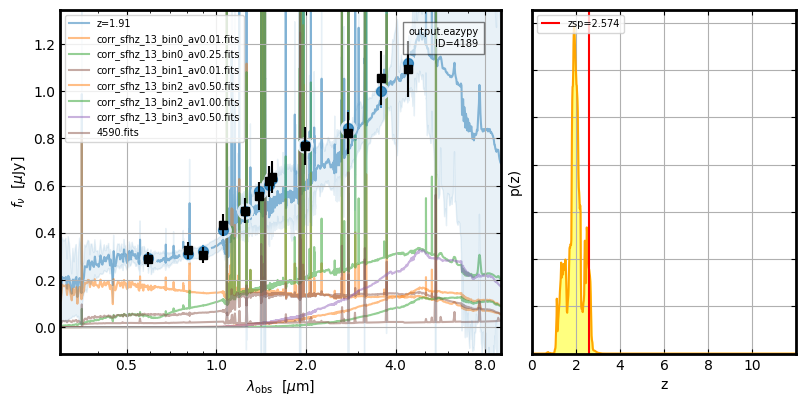

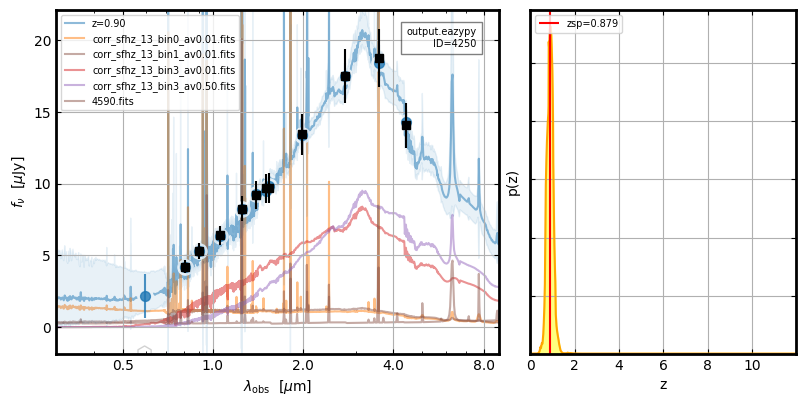

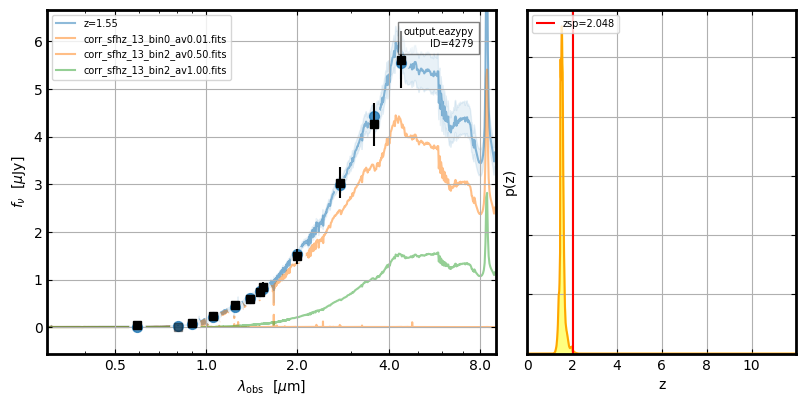

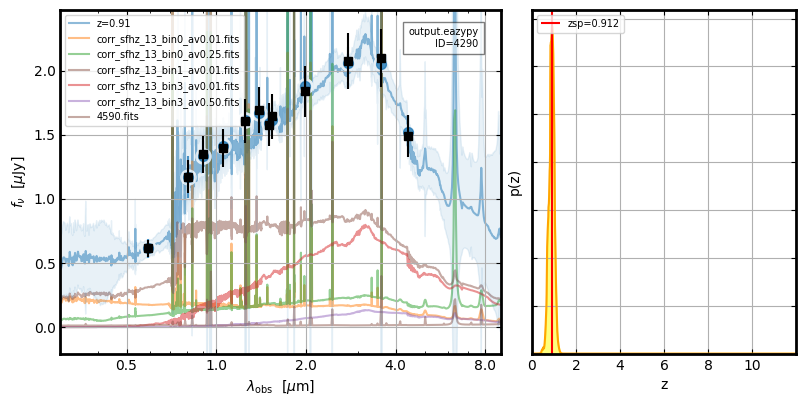

In [21]:
# Example: SEDs of the objects with the 4, 8, 12, 16, 20th IDs
plot_seds(dir_output, "output.eazypy.zout.fits", "output.eazypy.zphot.pickle",
          dz['id'][[4, 8, 12, 16, 20]], save_data=True)